# 04. 모델 학습·평가

02에서 만든 피처로 연평균 계약금을 예측한다.

**평가 방법**: 표본이 타자 93명·투수 46명뿐이라 train/test를 한 번 나누면
어떻게 쪼개느냐에 따라 점수가 크게 흔들린다.
그래서 **5-fold 교차검증을 5회 반복한 OOF(Out-of-Fold) 예측**으로 평가한다.
모든 선수가 '학습에 안 쓰인 상태'로 예측된다.

**지표**: R² · MSE · RMSE · MAE 네 가지를 **억 원 단위로 되돌려** 계산한다.

## 0. 환경 설정

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA = ROOT / "data"
CHARTS = ROOT / "output" / "charts" / "notebook"
CHARTS.mkdir(parents=True, exist_ok=True)

# 순서 주의: seaborn의 set_style이 font.family를 sans-serif로 되돌린다.
# 폰트를 먼저 잡고 스타일을 나중에 걸면 한글이 전부 네모로 깨진다.
sns.set_style("whitegrid")

try:
    import koreanize_matplotlib  # noqa: F401
except ImportError:
    from matplotlib import font_manager
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for candidate in ("NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"):
        if candidate in installed:
            plt.rcParams["font.family"] = candidate
            plt.rcParams["font.sans-serif"] = [candidate]
            break
    else:
        print("경고: 한글 폰트를 못 찾았다. 라벨이 네모로 나올 수 있다.")

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

print("루트:", ROOT)
print("폰트:", plt.rcParams["font.family"])

루트: /Users/tina/Project/SalaryCast_AI
폰트: ['NanumGothic']


In [2]:
import joblib
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RepeatedKFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from src.features import HITTER_PCT_COLS, PITCHER_PCT_COLS, add_percentile_ranks

SEED = 42
EXCLUDED = {"annual_avg_salary", "total_contract_amount", "contract_years",
            "player_name", "player_id", "team", "position", "pitcher_role", "seasons_used"}
print("준비 완료")

준비 완료


## 1. 데이터 준비

02와 같은 순서로 백분위 피처를 붙이고, 누수 컬럼을 빼고, 타깃을 로그로 바꾼다.

In [3]:
def prepare(csv_name, pct_cols, group_col):
    frame = pd.read_csv(DATA / csv_name)
    engineered = add_percentile_ranks(frame.copy(), pct_cols, group_col)
    y = np.log1p(engineered["annual_avg_salary"])
    cols = [c for c in engineered.columns
            if c not in EXCLUDED and pd.api.types.is_numeric_dtype(engineered[c])]
    return engineered[cols].astype(float), y, cols, engineered

X_h, y_h, cols_h, eng_h = prepare("hitter_training_v8.csv", HITTER_PCT_COLS, "position")
X_p, y_p, cols_p, eng_p = prepare("pitcher_training_v8.csv", PITCHER_PCT_COLS, "pitcher_role")

print(f"타자 X {X_h.shape} / 투수 X {X_p.shape}")

타자 X (93, 55) / 투수 X (46, 47)


## 2. 모델 후보

수업에서 다룬 기법을 단순한 것부터 차례로 올린다.
아래로 갈수록 표현력이 커지지만, 표본이 작으면 과적합 위험도 같이 커진다.

| 모델 | 성격 |
|---|---|
| LinearRegression | 다중선형회귀. 가장 단순한 기준선 |
| Ridge | 선형회귀에 규제를 더해 과적합을 누른다 |
| KNN | 비슷한 선수들의 평균. 비교용 |
| DecisionTree | 조건 분기. 해석은 쉽지만 혼자 쓰면 불안정 |
| RandomForest | 나무 여러 개의 평균 |
| XGBoost / LightGBM | 부스팅. 앞선 나무의 오차를 다음 나무가 보정 |

In [4]:
def make_models(seed=SEED):
    # market_level은 가장 이른 FA 연도에 참고할 과거가 없어 NaN이다.
    # 트리 계열은 NaN을 그대로 받지만 선형·KNN은 못 받아 중앙값으로 채운다.
    return {
        "LinearRegression": make_pipeline(
            SimpleImputer(strategy="median"), StandardScaler(), LinearRegression()),
        "Ridge": make_pipeline(
            SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=1.0)),
        "KNN": make_pipeline(
            SimpleImputer(strategy="median"), StandardScaler(),
            KNeighborsRegressor(n_neighbors=5)),
        "DecisionTree": DecisionTreeRegressor(max_depth=4, random_state=seed),
        "RandomForest": RandomForestRegressor(
            n_estimators=500, max_depth=6, min_samples_leaf=2, random_state=seed, n_jobs=1),
        "XGBoost": XGBRegressor(
            n_estimators=600, max_depth=3, learning_rate=0.05,
            subsample=0.7, colsample_bytree=0.7, reg_lambda=1.0,
            random_state=seed, verbosity=0, n_jobs=1),
        "LightGBM": LGBMRegressor(
            n_estimators=600, max_depth=3, learning_rate=0.05,
            subsample=0.7, colsample_bytree=0.7, min_child_samples=5,
            random_state=seed, verbose=-1, n_jobs=1),
    }

print("\n".join(make_models()))

LinearRegression
Ridge
KNN
DecisionTree
RandomForest
XGBoost
LightGBM


## 3. 평가 함수

로그로 학습했으므로 지표는 `expm1`로 되돌려서 낸다.
**사용자가 보는 단위가 억 원**이기 때문이다.

In [5]:
def score_in_billions(y_log, pred_log):
    actual = np.expm1(y_log)
    predicted = np.clip(np.expm1(pred_log), 0, None)
    mse = mean_squared_error(actual, predicted)
    return {"R2": r2_score(actual, predicted),
            "MSE": mse,
            "RMSE": float(np.sqrt(mse)),
            "MAE": mean_absolute_error(actual, predicted)}


def oof_predict(model, X, y, n_repeats=5):
    """반복 K-fold의 평균 OOF 예측. 표본이 작아 한 번의 분할로는 흔들린다."""
    cv = RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=SEED)
    accumulated = np.zeros(len(y))
    for train_idx, valid_idx in cv.split(X):
        fold = clone(model)
        fold.fit(X.iloc[train_idx], y.iloc[train_idx])
        accumulated[valid_idx] += fold.predict(X.iloc[valid_idx])
    return accumulated / n_repeats


def evaluate_all(X, y, label):
    rows, preds = [], {}
    for name, model in make_models().items():
        pred = oof_predict(model, X, y)
        preds[name] = pred
        rows.append({"모델": name, **score_in_billions(y, pred)})
    table = pd.DataFrame(rows).set_index("모델").sort_values("R2", ascending=False)
    print(f"[{label}] OOF 성능 (억 원 단위)")
    display(table.round(3))
    return table, preds

## 4. 타자 모델

In [6]:
table_h, preds_h = evaluate_all(X_h, y_h, '타자')

[타자] OOF 성능 (억 원 단위)


,R2,MSE,RMSE,MAE
모델,,,,
LightGBM,0.604,21.278,4.613,3.061
XGBoost,0.559,23.661,4.864,3.172
Ridge,0.483,27.759,5.269,3.680
RandomForest,0.458,29.108,5.395,3.734
KNN,0.437,30.237,5.499,3.605
DecisionTree,0.325,36.209,6.017,4.220
LinearRegression,-0.266,67.935,8.242,5.158


## 5. 투수 모델

In [7]:
table_p, preds_p = evaluate_all(X_p, y_p, '투수')

[투수] OOF 성능 (억 원 단위)


,R2,MSE,RMSE,MAE
모델,,,,
XGBoost,0.572,9.246,3.041,2.326
LightGBM,0.561,9.484,3.080,2.472
Ridge,0.474,11.363,3.371,2.632
RandomForest,0.465,11.551,3.399,2.671
KNN,0.443,12.023,3.467,2.501
DecisionTree,0.390,13.164,3.628,2.703
LinearRegression,-257.601,5584.469,74.729,20.033


## 6. 모델별 비교

단순한 모델(KNN·DecisionTree)과 앙상블의 차이를 눈으로 본다.

**규제 없는 최소제곱(LinearRegression)은 투수에서 무너진다.**
투수는 표본 46명에 피처가 47개다. 미지수가 방정식보다 많으니 계수가 발산하고,
학습에 안 쓰인 선수에서 예측이 터무니없이 나온다. R²가 음수라는 것은
**그냥 평균값을 답하는 것보다 못하다**는 뜻이다.
같은 선형 모델이라도 Ridge는 계수 크기에 벌점을 줘서 이걸 막는다.
왜 규제가 필요한지 보여주는 자리라 값을 지우지 않고 그대로 둔다.

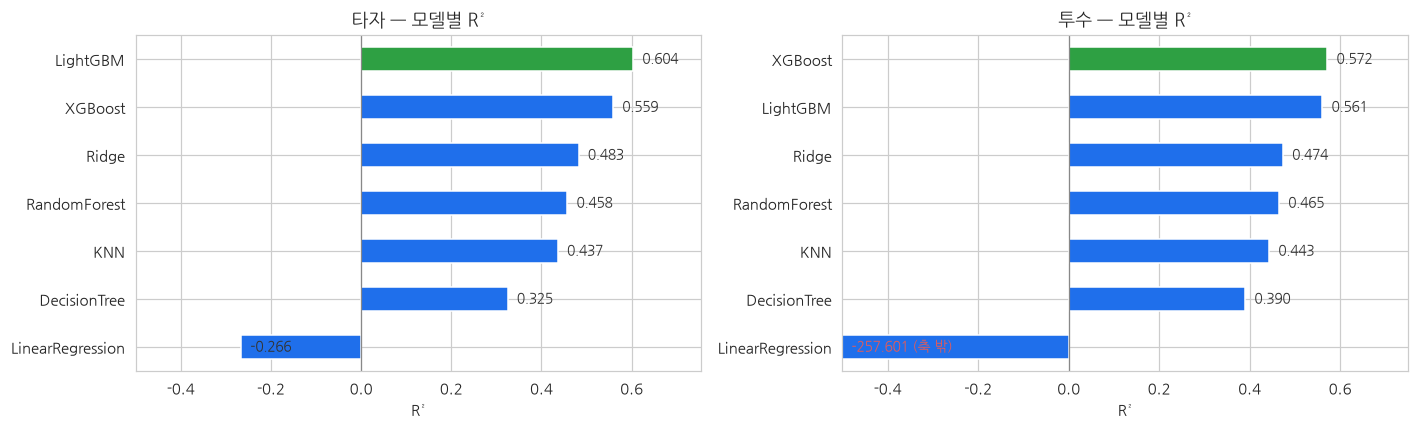

타자: 최고 LightGBM 0.604 / 최저 LinearRegression -0.266
투수: 최고 XGBoost 0.572 / 최저 LinearRegression -257.601


In [8]:
FLOOR = -0.5  # 이보다 낮은 값은 축을 다 잡아먹어서 잘라 그리고 숫자로만 적는다

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, table, title in [(axes[0], table_h, "타자"), (axes[1], table_p, "투수")]:
    ordered = table.sort_values("R2")
    best = ordered["R2"].max()
    drawn = ordered["R2"].clip(lower=FLOOR)
    colors = ["#2ea043" if v == best else "#1f6feb" for v in ordered["R2"]]
    drawn.plot(kind="barh", ax=ax, color=colors)

    ax.axvline(0, color="#888", lw=0.8)
    ax.set_xlim(FLOOR, max(0.75, best * 1.25))
    ax.set_title(f"{title} — 모델별 R²"); ax.set_xlabel("R²"); ax.set_ylabel("")

    for i, (value, shown) in enumerate(zip(ordered["R2"], drawn)):
        clipped = value < FLOOR
        ax.text(shown + 0.02, i,
                f"{value:.3f}" + (" (축 밖)" if clipped else ""),
                va="center", fontsize=9,
                color="#e05c5c" if clipped else "#333")

plt.tight_layout()
plt.savefig(CHARTS / "04_model_compare.png", bbox_inches="tight")
plt.show()

for label, table in [("타자", table_h), ("투수", table_p)]:
    worst = table["R2"].idxmin()
    print(f"{label}: 최고 {table['R2'].idxmax()} {table['R2'].max():.3f} / "
          f"최저 {worst} {table['R2'].min():.3f}")

## 7. 블렌딩 — 두 모델을 섞는다

트리 모델은 구간을 잘 나누고 선형 모델은 전체 추세를 잘 잡는다.
성격이 다른 둘을 가중 평균하면 서로의 약점을 덮는다.
가중치는 0부터 1까지 0.05 간격으로 전부 시도해 OOF R²가 가장 좋은 조합을 고른다.

**단일 모델보다 나을 때만 채택한다.**

In [9]:
def best_blend(preds, y):
    names = list(preds)
    best = (None, None, 1.0, {"R2": -np.inf})
    for i, first in enumerate(names):
        for second in names[i + 1:]:
            for weight in np.arange(0.0, 1.01, 0.05):
                blended = weight * preds[first] + (1 - weight) * preds[second]
                metrics = score_in_billions(y, blended)
                if metrics["R2"] > best[3]["R2"]:
                    best = (first, second, float(weight), metrics)
    return best

results = {}
for label, preds, y, table in [("타자", preds_h, y_h, table_h),
                               ("투수", preds_p, y_p, table_p)]:
    first, second, weight, metrics = best_blend(preds, y)
    single = table["R2"].max()
    print(f"[{label}] 최적 블렌드  {first} {weight:.2f} + {second} {1 - weight:.2f}")
    print(f"        R² {metrics['R2']:.3f} / RMSE {metrics['RMSE']:.2f}억 / "
          f"MAE {metrics['MAE']:.2f}억   (단일 최고 {single:.3f})")
    print(f"        채택: {'블렌드' if metrics['R2'] > single else '단일 모델'}\n")
    results[label] = {"first": first, "second": second, "weight": weight, "metrics": metrics,
                      "pred": weight * preds[first] + (1 - weight) * preds[second]}

[타자] 최적 블렌드  Ridge 0.25 + LightGBM 0.75
        R² 0.618 / RMSE 4.53억 / MAE 3.01억   (단일 최고 0.604)
        채택: 블렌드



[투수] 최적 블렌드  Ridge 0.45 + XGBoost 0.55
        R² 0.645 / RMSE 2.77억 / MAE 2.07억   (단일 최고 0.572)
        채택: 블렌드



## 8. 실제값 vs 예측값

점이 대각선에 가까울수록 잘 맞힌 것이다.
오른쪽 위(대형 계약)에서 흩어지는 것은 표본이 적어서다 — 20억 이상 계약이 많지 않다.

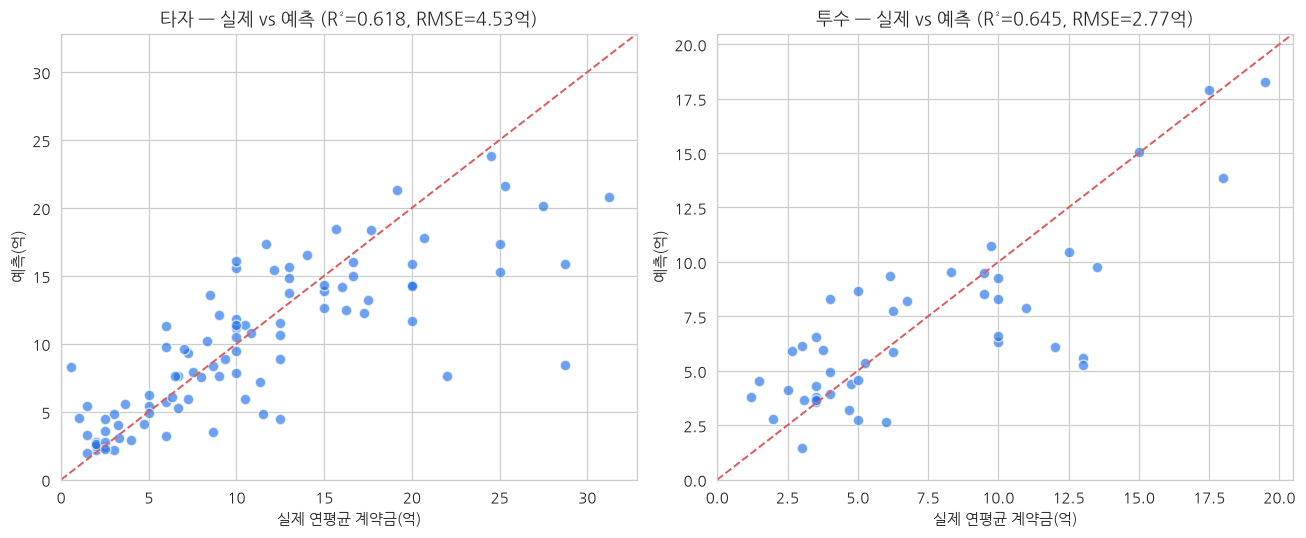

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label, y in [(axes[0], "타자", y_h), (axes[1], "투수", y_p)]:
    actual = np.expm1(y)
    predicted = np.clip(np.expm1(results[label]["pred"]), 0, None)
    ax.scatter(actual, predicted, alpha=0.65, s=48, color="#1f6feb", edgecolor="white")
    lim = [0, max(actual.max(), predicted.max()) * 1.05]
    ax.plot(lim, lim, ls="--", color="#e05c5c", lw=1.3)
    ax.set_xlim(lim); ax.set_ylim(lim)
    m = results[label]["metrics"]
    ax.set_title(f"{label} — 실제 vs 예측 (R²={m['R2']:.3f}, RMSE={m['RMSE']:.2f}억)")
    ax.set_xlabel("실제 연평균 계약금(억)"); ax.set_ylabel("예측(억)")
plt.tight_layout()
plt.savefig(CHARTS / "04_actual_vs_pred.png", bbox_inches="tight")
plt.show()

## 9. 무엇을 보고 예측했는가 (Feature Importance)

부스팅 모델이 분기에 얼마나 자주 썼는지를 본다.

> 주의: 이건 **모델 전체**의 경향이라 누구를 검색하든 순서가 같다.
> 실제 서비스 화면에서는 선수 한 명마다 SHAP으로 따로 계산한다.

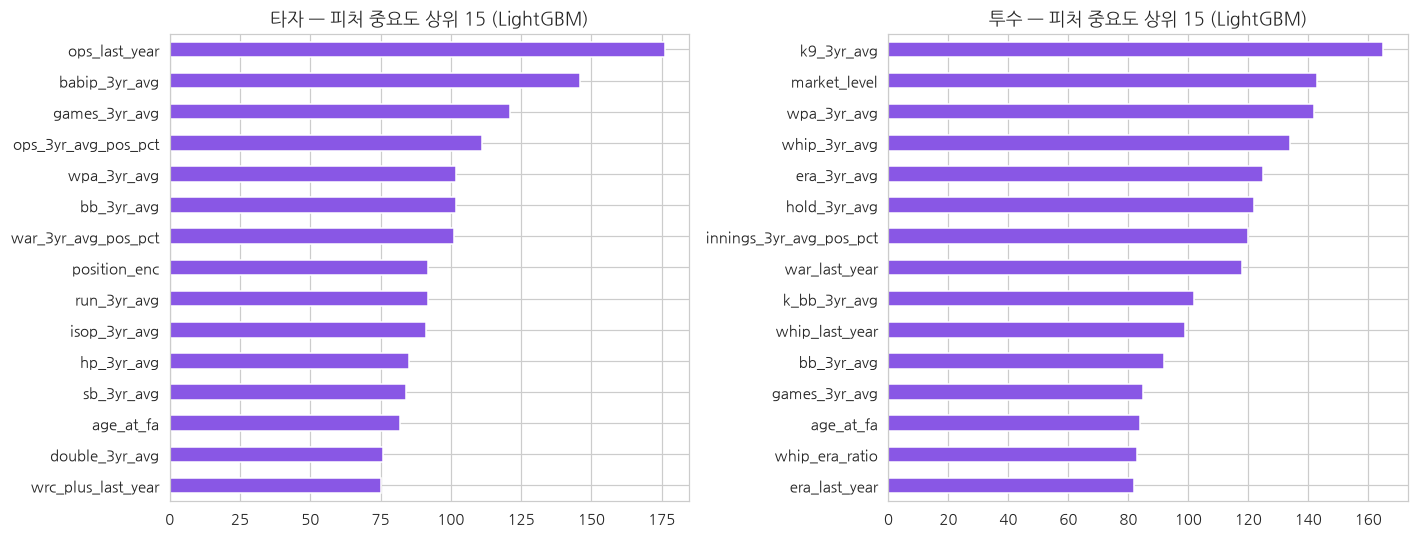

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, X, y, cols, title in [(axes[0], X_h, y_h, cols_h, "타자"),
                              (axes[1], X_p, y_p, cols_p, "투수")]:
    model = make_models()["LightGBM"]
    model.fit(X, y)
    importance = pd.Series(model.feature_importances_, index=cols).nlargest(15).sort_values()
    importance.plot(kind="barh", ax=ax, color="#8957e5")
    ax.set_title(f"{title} — 피처 중요도 상위 15 (LightGBM)")
plt.tight_layout()
plt.savefig(CHARTS / "04_feature_importance.png", bbox_inches="tight")
plt.show()

## 10. 모델 저장과 불러오기

`joblib`으로 저장한다. 예측할 때 필요한 것은 모델만이 아니다.
**어떤 피처를 어떤 순서로 넣어야 하는지**도 같이 저장해야 재현된다.

> 이 노트북은 `output/notebook_models/`에 저장한다.
> 서비스가 실제로 쓰는 `models/*.pkl`은 `scripts/train_model_v8.py`가 만든다.
> 노트북 실행이 운영 모델을 덮어쓰지 않게 분리해 둔다.

In [12]:
NB_MODELS = ROOT / "output" / "notebook_models"
NB_MODELS.mkdir(parents=True, exist_ok=True)

for label, X, y, cols in [("hitter", X_h, y_h, cols_h), ("pitcher", X_p, y_p, cols_p)]:
    info = results["타자" if label == "hitter" else "투수"]
    for name in {info["first"], info["second"]}:
        model = make_models()[name]
        model.fit(X, y)
        joblib.dump(model, NB_MODELS / f"{label}_{name.lower()}.pkl")
    joblib.dump({"features": cols, "first": info["first"], "second": info["second"],
                 "weight": info["weight"], "metrics": info["metrics"],
                 "target": "log1p(annual_avg_salary)"},
                NB_MODELS / f"{label}_meta.pkl")
    print(f"{label}: {info['first']} + {info['second']} 저장")

# 불러와서 한 명 예측해 보기
meta = joblib.load(NB_MODELS / "hitter_meta.pkl")
first = joblib.load(NB_MODELS / f"hitter_{meta['first'].lower()}.pkl")
second = joblib.load(NB_MODELS / f"hitter_{meta['second'].lower()}.pkl")

sample = X_h.iloc[[0]]
blended_log = (meta["weight"] * first.predict(sample)[0]
               + (1 - meta["weight"]) * second.predict(sample)[0])
predicted = float(np.expm1(blended_log))
print(f"\n{eng_h.iloc[0]['player_name']} "
      f"예측 {predicted:.2f}억 / 실제 {eng_h.iloc[0]['annual_avg_salary']:.2f}억")

hitter: Ridge + LightGBM 저장
pitcher: Ridge + XGBoost 저장

민병헌 예측 19.11억 / 실제 20.00억


## 11. 2차 보정 — 구단별 제시가

예측 연봉은 '시장 평균'이다. 실제 협상가는 구단 사정에 따라 다르다.
같은 선수라도 그 포지션이 급한 구단과 이미 채워진 구단이 부르는 값이 다르다.

```
제시가 = 예측 연봉 x (1 + 포지션 필요도 보정 + 윈나우 보정 + 샐러리캡 여유 보정)
```

이건 학습한 게 아니라 **도메인 규칙**이다. 모델과 분리해 둔 이유는
근거를 설명할 수 있어야 하고, 규칙만 따로 고칠 수 있어야 하기 때문이다.

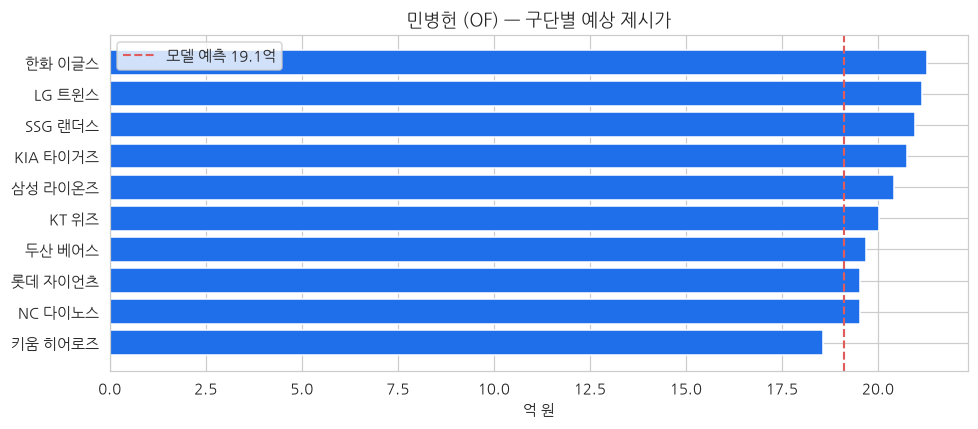

,team_name,need,win_now_score,cap_space_score,제시가
0,한화 이글스,0.9,0.8,0.8,21.28
1,LG 트윈스,0.8,0.8,0.9,21.15
2,SSG 랜더스,0.8,0.7,0.9,20.96
3,KIA 타이거즈,0.7,0.9,0.7,20.75
4,삼성 라이온즈,0.6,0.8,0.8,20.42
5,KT 위즈,0.7,0.6,0.6,20.02
6,두산 베어스,0.7,0.5,0.5,19.68
7,롯데 자이언츠,0.6,0.5,0.6,19.54
8,NC 다이노스,0.6,0.5,0.6,19.54
9,키움 히어로즈,0.5,0.3,0.4,18.57


In [13]:
teams = pd.read_csv(DATA / "teams.csv")
position_need = pd.read_csv(DATA / "position_need.csv")

target_player = eng_h.iloc[0]
position = target_player["position"]

need = position_need[position_need.position == position].set_index("team_name")["need_score"]
offers = teams.copy()
offers["need"] = offers["team_name"].map(need).fillna(0.5)
offers["제시가"] = (predicted * (1
                              + 0.15 * (offers["need"] - 0.5)
                              + 0.10 * (offers["win_now_score"] - 0.5)
                              + 0.08 * (offers["cap_space_score"] - 0.5))).round(2)
offers = offers.sort_values("제시가", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(offers["team_name"], offers["제시가"], color="#1f6feb")
ax.axvline(predicted, color="#e05c5c", ls="--", lw=1.4, label=f"모델 예측 {predicted:.1f}억")
ax.invert_yaxis()
ax.set_title(f"{target_player['player_name']} ({position}) — 구단별 예상 제시가")
ax.set_xlabel("억 원"); ax.legend()
plt.tight_layout()
plt.savefig(CHARTS / "04_team_offers.png", bbox_inches="tight")
plt.show()

display(offers[["team_name", "need", "win_now_score", "cap_space_score", "제시가"]]
        .reset_index(drop=True))

## 정리

| 대상 | 최종 모델 | R² | RMSE | MAE | 표본 |
|---|---|---|---|---|---|
| 타자 | LightGBM + Ridge 블렌드 | 0.618 | 4.53억 | 3.01억 | 93명 |
| 투수 | XGBoost + Ridge 블렌드 | 0.645 | 2.77억 | 2.07억 | 46명 |

**왜 이 구성인가**

- **타자/투수 분리** — 평가 지표 자체가 다르다. 한 모델에 넣으면 서로를 방해한다
- **로그 변환** — 연봉 분포가 오른쪽으로 크게 치우쳐 있다 (03)
- **반복 교차검증** — 표본이 100명 미만이라 단일 분할은 점수가 흔들린다
- **블렌딩** — 트리와 선형의 성격이 달라 섞으면 서로의 약점을 덮는다
- **누수 제거** — 총액·계약연수를 넣으면 지표가 치솟지만 서비스에서는 못 쓴다

**남은 한계**

- 표본이 절대적으로 작다. 특히 투수 46명은 피처 하나에도 지표가 크게 흔들린다
- 부상 이력, 협상 과정, 원소속팀 프리미엄 같은 비성적 요인은 담지 못했다
- 예측 상한이 실제 최고 계약 근처라, 그 위 구간은 표본이 없어 외삽이다